# Python Code Generator + Test Case Generator
## Built with LangGraph + Groq

```
User Request (natural language)
        ↓
  Requirements Extractor
        ↓
   Code Generator
        ↓
   Test Generator
        ↓
   Code Executor
     ↓       ↓
  [Pass]   [Fail]
     ↓       ↓
 Response  Refinement ──► Code Generator (retry loop, max 3)
```

## Cell 1: Imports

In [ ]:
import os
import re
import sys
import subprocess
import tempfile
import textwrap
import getpass
from typing import TypedDict, Optional, Literal

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, END

import gradio as gr

print('All imports successful')

## Cell 2: API Key & LLM Setup

In [ ]:
os.environ['GROQ_API_KEY'] = getpass.getpass('Enter your Groq API Key: ')

llm = ChatGroq(model='llama-3.3-70b-versatile', temperature=0)
print('LLM ready')

## Cell 3: LangGraph State

The state flows through every node. Each node reads what it needs and returns only the keys it updates.

In [ ]:
class CodeGenState(TypedDict):
    user_request:      str            # original natural-language description
    task_type:         str            # 'function' | 'class' | 'script'
    requirements:      str            # structured spec extracted by requirements node
    generated_code:    str            # Python code produced by code generator
    test_code:         str            # pytest tests produced by test generator
    execution_result:  str            # stdout/stderr from sandbox run
    execution_success: bool           # True if all tests passed
    retry_count:       int            # how many refinement attempts so far
    error_message:     str            # last error from executor
    final_response:    str            # formatted final answer shown to user

print('State schema defined')

## Cell 4: Graph Nodes

Each function is one **node** in the graph. It receives the full state, does its job, and returns a dict of updated keys only.

In [ ]:
MAX_RETRIES = 3

# ── Utility: strip markdown code fences ──────────────────────────────────────
def extract_code(text: str) -> str:
    match = re.search(r'```(?:python)?\n(.*?)```', text, re.DOTALL)
    return match.group(1).strip() if match else text.strip()


# ── Node 1: Requirements Extractor ───────────────────────────────────────────
def requirements_node(state: CodeGenState) -> dict:
    print('[REQUIREMENTS] Extracting structured spec...')
    prompt = f"""You are a software requirements analyst.
Extract a precise, structured specification from the user's request.

User request: {state['user_request']}

Return ONLY this format (no extra text):
TASK_TYPE: <function | class | script>
NAME: <function or class name>
DESCRIPTION: <one sentence what it does>
PARAMETERS: <param: type, ...  or  None>
RETURNS: <return type and description>
EDGE_CASES: <comma-separated edge cases to handle>"""

    response = llm.invoke(prompt).content.strip()
    lines = {}
    for line in response.splitlines():
        if ':' in line:
            k, v = line.split(':', 1)
            lines[k.strip()] = v.strip()

    task_type    = lines.get('TASK_TYPE', 'function').lower()
    requirements = response
    print(f'[REQUIREMENTS] Task type: {task_type}')
    print(f'[REQUIREMENTS]\n{requirements}\n')
    return {'task_type': task_type, 'requirements': requirements}


# ── Node 2: Code Generator ────────────────────────────────────────────────────
def code_generator_node(state: CodeGenState) -> dict:
    print('[CODE GEN] Generating Python code...')

    refinement_hint = ''
    if state.get('error_message') and state.get('retry_count', 0) > 0:
        refinement_hint = f"""
IMPORTANT — previous attempt failed with this error:
{state['error_message']}

Previous code that failed:
```python
{state.get('generated_code', '')}
```
Fix the issues above."""

    prompt = f"""You are an expert Python developer. Write clean, correct Python code.

Requirements:
{state['requirements']}
{refinement_hint}

Rules:
- No import statements unless strictly necessary
- No placeholder comments like "# TODO"
- Handle all edge cases listed in requirements
- Return ONLY the code block, no explanations

```python
# your code here
```"""

    raw = llm.invoke(prompt).content
    code = extract_code(raw)
    print(f'[CODE GEN] Generated {len(code.splitlines())} lines of code.')
    return {'generated_code': code, 'error_message': ''}


# ── Node 3: Test Generator ────────────────────────────────────────────────────
def test_generator_node(state: CodeGenState) -> dict:
    print('[TEST GEN] Generating pytest test cases...')
    prompt = f"""You are a Python testing expert. Write pytest test cases.

Requirements:
{state['requirements']}

Code to test:
```python
{state['generated_code']}
```

Rules:
- Write 4-6 test functions named test_*
- Cover: happy path, edge cases, error cases
- Use plain assert statements (no pytest.raises unless testing exceptions)
- Do NOT import the code — it will be injected above your tests
- Return ONLY the code block

```python
# tests here
```"""

    raw = llm.invoke(prompt).content
    test_code = extract_code(raw)
    print(f'[TEST GEN] Generated {len(test_code.splitlines())} lines of tests.')
    return {'test_code': test_code}


# ── Node 4: Code Executor (sandbox) ──────────────────────────────────────────
def executor_node(state: CodeGenState) -> dict:
    print('[EXECUTOR] Running code + tests in sandbox...')
    combined = textwrap.dedent(f"""
{state['generated_code']}

{state['test_code']}

# Auto-run all test functions
import sys
_passed = 0
_failed = 0
for _name, _fn in list(globals().items()):
    if _name.startswith('test_') and callable(_fn):
        try:
            _fn()
            print(f'  PASS  {{_name}}')
            _passed += 1
        except Exception as _e:
            print(f'  FAIL  {{_name}}: {{_e}}')
            _failed += 1
print(f'\\nResults: {{_passed}} passed, {{_failed}} failed')
if _failed > 0:
    sys.exit(1)
    """).strip()

    with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as f:
        f.write(combined)
        tmp_path = f.name

    result = subprocess.run(
        [sys.executable, tmp_path],
        capture_output=True, text=True, timeout=15
    )
    output  = (result.stdout + result.stderr).strip()
    success = result.returncode == 0

    print(f'[EXECUTOR] Success={success}')
    print(f'[EXECUTOR] Output:\n{output}\n')
    return {
        'execution_result':  output,
        'execution_success': success,
        'error_message':     '' if success else output,
    }


# ── Node 5: Refinement ────────────────────────────────────────────────────────
def refinement_node(state: CodeGenState) -> dict:
    new_retry = state.get('retry_count', 0) + 1
    print(f'[REFINEMENT] Retry attempt {new_retry}/{MAX_RETRIES}...')
    return {'retry_count': new_retry}


# ── Node 6: Response Formatter ────────────────────────────────────────────────
def response_node(state: CodeGenState) -> dict:
    print('[RESPONSE] Formatting final output...')
    if state['execution_success']:
        status = 'All tests passed'
        response = (
            f"## Generated Code\n"
            f"```python\n{state['generated_code']}\n```\n\n"
            f"## Test Cases\n"
            f"```python\n{state['test_code']}\n```\n\n"
            f"## Execution Result\n"
            f"```\n{state['execution_result']}\n```\n\n"
            f"**{status}** after {state.get('retry_count', 0)} refinement(s)."
        )
    else:
        response = (
            f"## Generated Code (last attempt)\n"
            f"```python\n{state['generated_code']}\n```\n\n"
            f"## Test Cases\n"
            f"```python\n{state['test_code']}\n```\n\n"
            f"## Execution Result\n"
            f"```\n{state['execution_result']}\n```\n\n"
            f"**Tests did not pass** after {state.get('retry_count', 0)} refinement(s). "
            f"Please review the code manually."
        )
    return {'final_response': response}


print('All nodes defined')

## Cell 5: Routing Functions (Conditional Edges)

In [ ]:
def route_after_executor(state: CodeGenState) -> str:
    """
    After the executor runs:
    - tests passed              → response_node
    - tests failed + retries left → refinement_node
    - tests failed + no retries  → response_node (with error)
    """
    if state['execution_success']:
        print('[ROUTER] Tests PASSED → response')
        return 'response_node'
    if state.get('retry_count', 0) < MAX_RETRIES:
        print(f"[ROUTER] Tests FAILED (retry {state.get('retry_count',0)}/{MAX_RETRIES}) → refinement")
        return 'refinement_node'
    print('[ROUTER] Max retries reached → response')
    return 'response_node'


print('Routing function ready')

## Cell 6: Build & Compile the LangGraph

In [ ]:
builder = StateGraph(CodeGenState)

# ── Add nodes ────────────────────────────────────────────────────────────────
builder.add_node('requirements_extractor', requirements_node)
builder.add_node('code_generator',         code_generator_node)
builder.add_node('test_generator',         test_generator_node)
builder.add_node('code_executor',          executor_node)
builder.add_node('refinement_node',        refinement_node)
builder.add_node('response_node',          response_node)

# ── Linear edges ─────────────────────────────────────────────────────────────
builder.set_entry_point('requirements_extractor')
builder.add_edge('requirements_extractor', 'code_generator')
builder.add_edge('code_generator',         'test_generator')
builder.add_edge('test_generator',         'code_executor')
builder.add_edge('response_node',          END)

# ── Conditional edge: after executor → pass or retry ─────────────────────────
builder.add_conditional_edges(
    'code_executor',
    route_after_executor,
    {
        'response_node':  'response_node',
        'refinement_node': 'refinement_node',
    }
)

# ── Retry loop: refinement → code_generator ──────────────────────────────────
builder.add_edge('refinement_node', 'code_generator')

# ── Compile ───────────────────────────────────────────────────────────────────
graph = builder.compile()
print('LangGraph compiled successfully!')

## Cell 7: LangGraph Flow Diagram

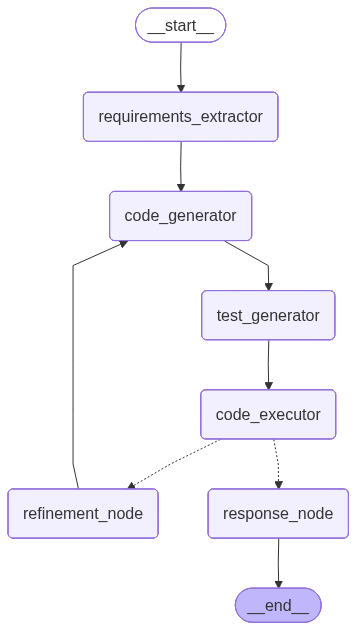

In [20]:
# Try to render as PNG (requires pygraphviz or mermaid)
try:
    from IPython.display import display, Image
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: print Mermaid source
    print(graph.get_graph().draw_mermaid())

## Cell 8: Helper — Run a Request Through the Graph

In [ ]:
def generate_code(user_request: str) -> dict:
    """Run the full LangGraph pipeline for a user request."""
    initial_state: CodeGenState = {
        'user_request':      user_request,
        'task_type':         '',
        'requirements':      '',
        'generated_code':    '',
        'test_code':         '',
        'execution_result':  '',
        'execution_success': False,
        'retry_count':       0,
        'error_message':     '',
        'final_response':    '',
    }
    return graph.invoke(initial_state)

print('generate_code() helper ready')

## Cell 9: Test Examples

In [ ]:
# Test 1 — Simple function
print('=' * 60)
print('TEST 1: Simple function')
print('=' * 60)
result = generate_code('Write a function that checks if a number is prime')
print('\n--- FINAL RESPONSE ---')
print(result['final_response'])

In [ ]:
# Test 2 — String manipulation
print('=' * 60)
print('TEST 2: String manipulation')
print('=' * 60)
result = generate_code(
    'Write a function that reverses words in a sentence but keeps punctuation attached to words'
)
print('\n--- FINAL RESPONSE ---')
print(result['final_response'])

In [ ]:
# Test 3 — Data structure
print('=' * 60)
print('TEST 3: Data structure')
print('=' * 60)
result = generate_code(
    'Write a function that finds the two numbers in a list that add up to a target sum'
)
print('\n--- FINAL RESPONSE ---')
print(result['final_response'])

## Cell 10: Gradio Chat UI

In [ ]:
def gradio_generate(message: str, history: list) -> str:
    try:
        result = generate_code(message)
        return result['final_response']
    except Exception as e:
        return f'Error: {str(e)}'


demo = gr.ChatInterface(
    fn=gradio_generate,
    title='Python Code Generator + Test Case Generator',
    description='Describe what you want in plain English. The system generates Python code, test cases, executes them, and auto-refines on failures.',
    examples=[
        'Write a function to check if a string is a palindrome',
        'Write a function that finds the factorial of a number recursively',
        'Write a function that merges two sorted lists into one sorted list',
        'Write a function that counts the frequency of each word in a string',
    ],
)

demo.launch(debug=True, share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a5c726e2f35b86e829.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


[REQUIREMENTS] Extracting structured spec...
[REQUIREMENTS] Task type: function
[REQUIREMENTS]
TASK_TYPE: function
NAME: greet_user
DESCRIPTION: Returns a greeting message to the user.
PARAMETERS: None
RETURNS: string, a greeting message
EDGE_CASES: empty input, null input, non-string input

[CODE GEN] Generating Python code...
[CODE GEN] Generated 11 lines of code.
[TEST GEN] Generating pytest test cases...
[TEST GEN] Generated 26 lines of tests.
[EXECUTOR] Running code + tests in sandbox...
[EXECUTOR] Success=False
[EXECUTOR] Output:
Hello, user!
  PASS  test_greet_user_happy_path
  PASS  test_greet_user_empty_input
  PASS  test_greet_user_null_input
  PASS  test_greet_user_non_string_input
  FAIL  test_greet_user_error_case: __code__ must be set to a code object
  PASS  test_greet_user_return_type

Results: 5 passed, 1 failed

[ROUTER] Tests FAILED (retry 0/3) → refinement
[REFINEMENT] Retry attempt 1/3...
[CODE GEN] Generating Python code...
[CODE GEN] Generated 14 lines of code.
[